# Phase 1 — Input & Coordinate System

**Grid Engine: Variable-Resolution 2.5D Semantic Elevation Grid**

This notebook loads and validates the synthetic LiDAR dataset,
establishes coordinate conventions, computes radial distances,
and prepares clean output for Phase 2.

**Input:** `synthetic_structured_lidar.npy` — 120k points with `[X, Y, Z, Label, Confidence, Intensity]`

**Output:** `phase1_output.npz` — validated arrays + metadata for Phase 2

## 1. Configuration & Constants

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os
import time

# ── File paths ──────────────────────────────────────────────────
# CHANGE THIS PATH to the actual file we generated in Track 1!
DATA_FILE = "/kaggle/input/datasets/dipangsu/dl-output-sih/SIH_Segmented_Seq08/000000_segmented.npy"

# ── Sensor origin (LiDAR position in the scene) ────────────────
SENSOR_ORIGIN = np.array([0.0, 0.0, 0.0])

# ── Expected data format ────────────────────────────────────────
EXPECTED_COLUMNS = 6   # [X, Y, Z, Label, Confidence, Intensity]

# ── Semantic label mapping ──────────────────────────────────────
# Updated to the 19 classes output by our RandLA-Net model!
LABEL_NAMES = {
    0: "Car",
    1: "Bicycle",
    2: "Motorcycle",
    3: "Truck",
    4: "Other-vehicle",
    5: "Person",
    6: "Bicyclist",
    7: "Motorcyclist",
    8: "Road",
    9: "Parking",
    10: "Sidewalk",
    11: "Other-ground",
    12: "Building",
    13: "Fence",
    14: "Vegetation",
    15: "Trunk",
    16: "Terrain",
    17: "Pole",
    18: "Traffic-sign",
}
VALID_LABELS = set(LABEL_NAMES.keys())

# ── Radial distance bands & base resolutions ───────────────────
# Format: (min_distance, max_distance, base_resolution_m)
DISTANCE_BANDS = [
    (0,   10,  0.05),   # 0–10 m  → 5 cm
    (10,  30,  0.10),   # 10–30 m → 10 cm
    (30,  60,  0.25),   # 30–60 m → 25 cm
    (60, 100,  0.50),   # 60–100 m → 50 cm
]

# ── Map boundary padding ───────────────────────────────────────
BOUNDARY_PADDING_M = 1.0

# ── Visualization settings ─────────────────────────────────────
# Colors for each semantic class (one per label)
CLASS_COLORS = {
    0: "#ff0000",   # Car - red
    1: "#ff8000",   # Bicycle - orange
    2: "#ff8000",   # Motorcycle - orange
    3: "#800000",   # Truck - dark red
    4: "#800000",   # Other-vehicle - dark red
    5: "#0000ff",   # Person - blue
    6: "#0000ff",   # Bicyclist - blue
    7: "#0000ff",   # Motorcyclist - blue
    8: "#808080",   # Road - gray
    9: "#606060",   # Parking - dark gray
    10: "#a0a0a0",  # Sidewalk - light gray
    11: "#c0c0c0",  # Other-ground - lighter gray
    12: "#ffd700",  # Building - yellow
    13: "#8b4513",  # Fence - brown
    14: "#008000",  # Vegetation - green
    15: "#8b4513",  # Trunk - brown
    16: "#90ee90",  # Terrain - light green
    17: "#d3d3d3",  # Pole - very light gray
    18: "#ff00ff",  # Traffic-sign - magenta
}

# For scatter plots, subsample to this many points for readability
VIS_MAX_POINTS = 20000

print("✓ Configuration loaded")
print(f"  Data file    : {DATA_FILE}")
print(f"  Sensor origin: {SENSOR_ORIGIN}")
print(f"  Labels       : {LABEL_NAMES}")

✓ Configuration loaded
  Data file    : /kaggle/input/datasets/dipangsu/dl-output-sih/SIH_Segmented_Seq08/000000_segmented.npy
  Sensor origin: [0. 0. 0.]
  Labels       : {0: 'Car', 1: 'Bicycle', 2: 'Motorcycle', 3: 'Truck', 4: 'Other-vehicle', 5: 'Person', 6: 'Bicyclist', 7: 'Motorcyclist', 8: 'Road', 9: 'Parking', 10: 'Sidewalk', 11: 'Other-ground', 12: 'Building', 13: 'Fence', 14: 'Vegetation', 15: 'Trunk', 16: 'Terrain', 17: 'Pole', 18: 'Traffic-sign'}


## 2. Data Loading & Shape Validation

In [3]:
# ── Load raw data ───────────────────────────────────────────────
assert os.path.exists(DATA_FILE), f"Data file not found: {DATA_FILE}"

raw_data = np.load(DATA_FILE)

print(f"Loaded: {DATA_FILE}")
print(f"  Shape : {raw_data.shape}")
print(f"  Dtype : {raw_data.dtype}")
print(f"  Memory: {raw_data.nbytes / 1024:.1f} KB ({raw_data.nbytes / (1024*1024):.2f} MB)")

# ── Shape assertions ───────────────────────────────────────────
assert raw_data.ndim == 2, f"Expected 2D array, got {raw_data.ndim}D"
assert raw_data.shape[1] == EXPECTED_COLUMNS, (
    f"Expected {EXPECTED_COLUMNS} columns, got {raw_data.shape[1]}"
)
assert raw_data.shape[0] > 0, "Dataset is empty"

N_POINTS = raw_data.shape[0]
print(f"\n✓ Shape validation passed: {N_POINTS} points × {EXPECTED_COLUMNS} columns")

Loaded: /kaggle/input/datasets/dipangsu/dl-output-sih/SIH_Segmented_Seq08/000000_segmented.npy
  Shape : (123389, 6)
  Dtype : float32
  Memory: 2891.9 KB (2.82 MB)

✓ Shape validation passed: 123389 points × 6 columns


## 3. Column Extraction

In [4]:
# ── Separate into meaningful arrays ─────────────────────────────
# We keep the raw data untouched and work with views/copies.
points_xyz  = raw_data[:, 0:3].astype(np.float64)   # (N, 3)  — higher precision for geometry
labels      = raw_data[:, 3].astype(np.int32)        # (N,)    — integer class IDs
confidence  = raw_data[:, 4].astype(np.float32)      # (N,)    — DL prediction confidence
intensity   = raw_data[:, 5].astype(np.float32)      # (N,)    — LiDAR return intensity

print("Column extraction:")
print(f"  points_xyz : {points_xyz.shape}, dtype={points_xyz.dtype}")
print(f"  labels     : {labels.shape},      dtype={labels.dtype}")
print(f"  confidence : {confidence.shape},   dtype={confidence.dtype}")
print(f"  intensity  : {intensity.shape},    dtype={intensity.dtype}")
print(f"\n✓ All arrays have {N_POINTS} rows — consistent")

Column extraction:
  points_xyz : (123389, 3), dtype=float64
  labels     : (123389,),      dtype=int32
  confidence : (123389,),   dtype=float32
  intensity  : (123389,),    dtype=float32

✓ All arrays have 123389 rows — consistent


## 4. Data Quality Checks

In [5]:
print("=" * 60)
print("DATA QUALITY CHECKS")
print("=" * 60)

all_passed = True

# ── Check 1: NaN values ────────────────────────────────────────
nan_xyz  = np.isnan(points_xyz).sum()
nan_lab  = np.isnan(raw_data[:, 3]).sum()
nan_conf = np.isnan(confidence).sum()
nan_int  = np.isnan(intensity).sum()
total_nan = nan_xyz + nan_lab + nan_conf + nan_int

if total_nan == 0:
    print("✓ NaN check         : PASS — zero NaN values")
else:
    print(f"✗ NaN check         : FAIL — {total_nan} NaN values found")
    print(f"    XYZ: {nan_xyz}, Labels: {nan_lab}, Conf: {nan_conf}, Int: {nan_int}")
    all_passed = False

# ── Check 2: Infinite values ───────────────────────────────────
inf_xyz  = np.isinf(points_xyz).sum()
inf_conf = np.isinf(confidence).sum()
inf_int  = np.isinf(intensity).sum()
total_inf = inf_xyz + inf_conf + inf_int

if total_inf == 0:
    print("✓ Inf check         : PASS — zero infinite values")
else:
    print(f"✗ Inf check         : FAIL — {total_inf} infinite values found")
    all_passed = False

# ── Check 3: Label validity ────────────────────────────────────
unique_labels = set(np.unique(labels).tolist())
invalid_labels = unique_labels - VALID_LABELS

if len(invalid_labels) == 0:
    print(f"✓ Label check       : PASS — all labels in {VALID_LABELS}")
else:
    print(f"✗ Label check       : FAIL — invalid labels: {invalid_labels}")
    all_passed = False

# ── Check 4: Confidence range [0, 1] ───────────────────────────
conf_min, conf_max = confidence.min(), confidence.max()
if 0.0 <= conf_min and conf_max <= 1.0:
    print(f"✓ Confidence range  : PASS — [{conf_min:.4f}, {conf_max:.4f}]")
else:
    print(f"✗ Confidence range  : FAIL — [{conf_min:.4f}, {conf_max:.4f}]")
    all_passed = False

# ── Check 5: Intensity range [0, 1] ────────────────────────────
int_min, int_max = intensity.min(), intensity.max()
if 0.0 <= int_min and int_max <= 1.0:
    print(f"✓ Intensity range   : PASS — [{int_min:.4f}, {int_max:.4f}]")
else:
    print(f"✗ Intensity range   : FAIL — [{int_min:.4f}, {int_max:.4f}]")
    all_passed = False

# ── Summary ────────────────────────────────────────────────────
print("=" * 60)
if all_passed:
    print("✓ ALL DATA QUALITY CHECKS PASSED")
else:
    print("✗ SOME CHECKS FAILED — investigate before proceeding")
print("=" * 60)

DATA QUALITY CHECKS
✓ NaN check         : PASS — zero NaN values
✓ Inf check         : PASS — zero infinite values
✓ Label check       : PASS — all labels in {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18}
✓ Confidence range  : PASS — [0.0205, 0.4741]
✓ Intensity range   : PASS — [0.0000, 0.9900]
✓ ALL DATA QUALITY CHECKS PASSED


## 5. Statistical Summary

In [7]:
for label_id in sorted(LABEL_NAMES.keys()):
    mask = (labels == label_id)
    count = int(mask.sum())

    if count == 0:
        continue

    pct = 100.0 * count / N_POINTS
    pts = points_xyz[mask]

    x_range = f"[{pts[:,0].min():.2f}, {pts[:,0].max():.2f}]"
    y_range = f"[{pts[:,1].min():.2f}, {pts[:,1].max():.2f}]"
    z_range = f"[{pts[:,2].min():.2f}, {pts[:,2].max():.2f}]"

    name = LABEL_NAMES[label_id]

    print(
        f"{label_id:<5} {name:<14} "
        f"{count:>7} {pct:>7.2f}% "
        f"{x_range:>16} {y_range:>16} {z_range:>16}"
    )

0     Car               1641    1.33%  [-77.98, 43.41]  [-21.77, 36.08]    [-3.34, 1.22]
4     Other-vehicle       70    0.06%  [-16.90, 38.36]   [-18.11, 7.92]    [-2.02, 0.16]
6     Bicyclist            3    0.00%   [61.25, 61.30]   [-2.49, -2.20] [-25.21, -25.19]
8     Road             26972   21.86%  [-78.70, 66.86]  [-11.93, 37.56]  [-27.64, -1.20]
9     Parking           6125    4.96%  [-27.48, 28.27]  [-18.50, 12.91]   [-2.52, -1.19]
10    Sidewalk         15910   12.89%  [-70.54, 65.06]  [-28.41, 38.33]   [-3.56, -0.70]
11    Other-ground      3302    2.68%  [-79.60, 75.11]  [-67.12, 61.58]    [-5.28, 0.36]
12    Building          3301    2.68%  [-78.17, 79.00]  [-64.20, 57.69]    [-3.06, 2.87]
13    Fence             2458    1.99%  [-73.21, 68.19]  [-60.17, 38.23]    [-3.16, 1.78]
14    Vegetation       25682   20.81%  [-76.74, 78.63]  [-76.86, 78.23]    [-6.58, 2.82]
15    Trunk             4421    3.58%  [-73.69, 72.03]  [-79.92, 75.74]    [-3.69, 2.96]
16    Terrain        

## 6. Radial Distance Calculation

In [8]:
# ── Compute radial distance from sensor origin ─────────────────
# r = sqrt((x - ox)^2 + (y - oy)^2)  — 2D radial distance in XY plane
dx = points_xyz[:, 0] - SENSOR_ORIGIN[0]
dy = points_xyz[:, 1] - SENSOR_ORIGIN[1]
radial_distance = np.sqrt(dx**2 + dy**2)

print("Radial distance statistics:")
print(f"  Min  : {radial_distance.min():.4f} m")
print(f"  Max  : {radial_distance.max():.4f} m")
print(f"  Mean : {radial_distance.mean():.4f} m")
print(f"  Median: {np.median(radial_distance):.4f} m")

# ── Distribution across resolution bands ───────────────────────
print(f"\n{'Band':<14} {'Resolution':>10} {'Points':>8} {'%':>7}")
print("-" * 42)

band_counts = []
for r_min, r_max, res in DISTANCE_BANDS:
    mask = (radial_distance >= r_min) & (radial_distance < r_max)
    count = mask.sum()
    pct = 100.0 * count / N_POINTS
    band_counts.append(count)
    print(f"{r_min:>3}–{r_max:<4} m    {res*100:>5.0f} cm    {count:>8} {pct:>6.1f}%")

# Points beyond all bands (> 100 m)
beyond_mask = radial_distance >= DISTANCE_BANDS[-1][1]
beyond_count = beyond_mask.sum()
band_counts.append(beyond_count)
print(f"{'> 100 m':<14} {'N/A':>10} {beyond_count:>8} {100.0*beyond_count/N_POINTS:>6.1f}%")

total_banded = sum(band_counts)
print(f"\n{'Total':>14} {'':>10} {total_banded:>8}")
assert total_banded == N_POINTS, (
    f"Band assignment mismatch: {total_banded} != {N_POINTS}"
)
print(f"\n✓ All {N_POINTS} points assigned to a band (including 'beyond')")

Radial distance statistics:
  Min  : 1.2399 m
  Max  : 80.0020 m
  Mean : 15.7594 m
  Median: 11.2432 m

Band           Resolution   Points       %
------------------------------------------
  0–10   m        5 cm       55373   44.9%
 10–30   m       10 cm       51949   42.1%
 30–60   m       25 cm       13893   11.3%
 60–100  m       50 cm        2174    1.8%
> 100 m               N/A        0    0.0%

         Total              123389

✓ All 123389 points assigned to a band (including 'beyond')


## 7. Map Boundary Establishment

In [9]:
# ── Axis-aligned bounding box + padding ─────────────────────────
x_min_raw, x_max_raw = points_xyz[:, 0].min(), points_xyz[:, 0].max()
y_min_raw, y_max_raw = points_xyz[:, 1].min(), points_xyz[:, 1].max()
z_min_raw, z_max_raw = points_xyz[:, 2].min(), points_xyz[:, 2].max()

# Padded boundaries for the 2D map
x_min_map = x_min_raw - BOUNDARY_PADDING_M
x_max_map = x_max_raw + BOUNDARY_PADDING_M
y_min_map = y_min_raw - BOUNDARY_PADDING_M
y_max_map = y_max_raw + BOUNDARY_PADDING_M

map_width  = x_max_map - x_min_map
map_height = y_max_map - y_min_map

print("Map boundaries (padded):")
print(f"  X: [{x_min_map:.2f}, {x_max_map:.2f}] m  (width  = {map_width:.2f} m)")
print(f"  Y: [{y_min_map:.2f}, {y_max_map:.2f}] m  (height = {map_height:.2f} m)")
print(f"  Z: [{z_min_raw:.2f}, {z_max_raw:.2f}] m  (elevation range, no padding)")
print(f"\n  Sensor origin: {SENSOR_ORIGIN}")
print(f"  Padding: {BOUNDARY_PADDING_M} m")

# Store in a dict for downstream phases
map_bounds = {
    "x_min": float(x_min_map),
    "x_max": float(x_max_map),
    "y_min": float(y_min_map),
    "y_max": float(y_max_map),
    "z_min": float(z_min_raw),
    "z_max": float(z_max_raw),
}
print(f"\n✓ Map boundaries established")

Map boundaries (padded):
  X: [-80.60, 80.00] m  (width  = 160.61 m)
  Y: [-80.92, 79.37] m  (height = 160.28 m)
  Z: [-27.64, 2.96] m  (elevation range, no padding)

  Sensor origin: [0. 0. 0.]
  Padding: 1.0 m

✓ Map boundaries established


## 8. Visualizations

### 8.1 — 3D Scatter Plot (colored by semantic class)

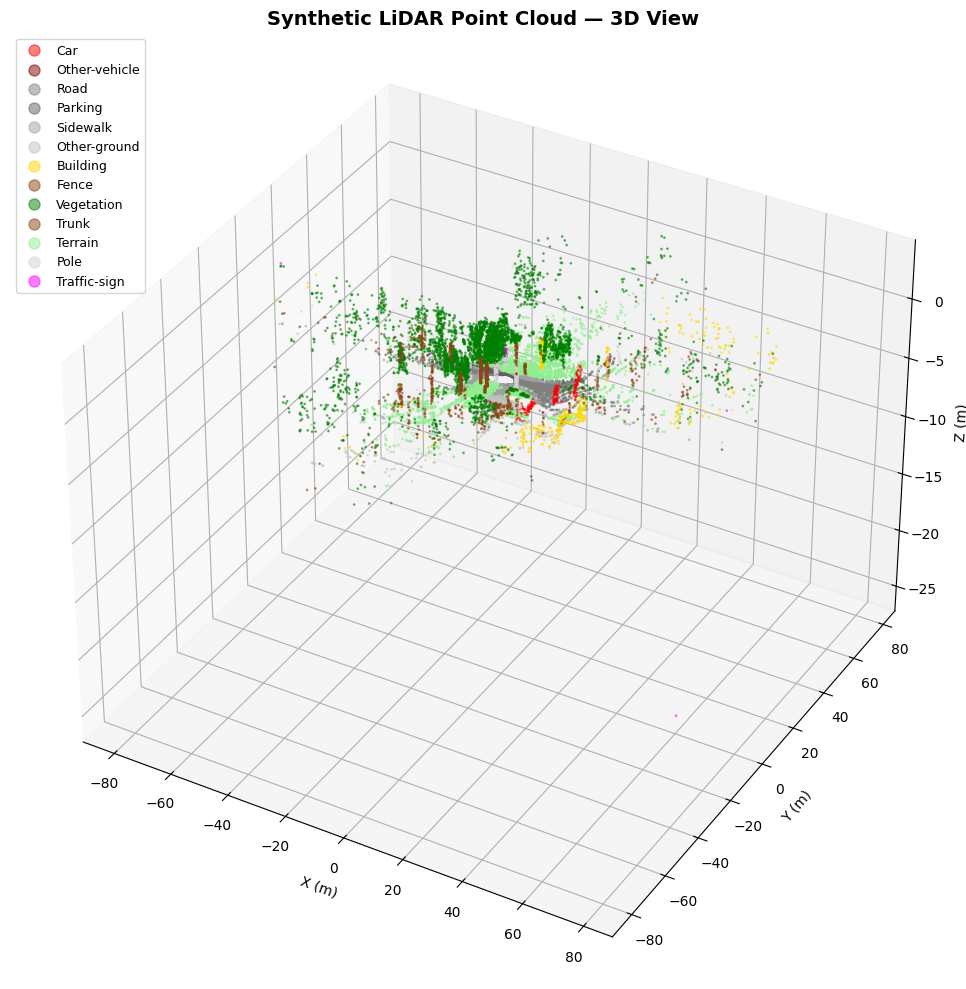

✓ Saved: vis_01_3d_pointcloud.png


In [10]:
# Subsample for 3D visualization performance
np.random.seed(0)
vis_idx = np.random.choice(N_POINTS, min(VIS_MAX_POINTS, N_POINTS), replace=False)

fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

for label_id in sorted(LABEL_NAMES.keys()):
    mask = labels[vis_idx] == label_id
    if mask.sum() == 0:
        continue
    pts = points_xyz[vis_idx][mask]
    ax.scatter(
        pts[:, 0], pts[:, 1], pts[:, 2],
        c=CLASS_COLORS[label_id],
        s=1, alpha=0.5,
        label=LABEL_NAMES[label_id]
    )

ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_zlabel("Z (m)")
ax.set_title("Synthetic LiDAR Point Cloud — 3D View", fontsize=14, fontweight='bold')
ax.legend(loc='upper left', markerscale=8, fontsize=9)
ax.view_init(elev=35, azim=-60)
plt.tight_layout()
plt.savefig("vis_01_3d_pointcloud.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: vis_01_3d_pointcloud.png")

### 8.2 — Top-Down Bird's-Eye View (XY)

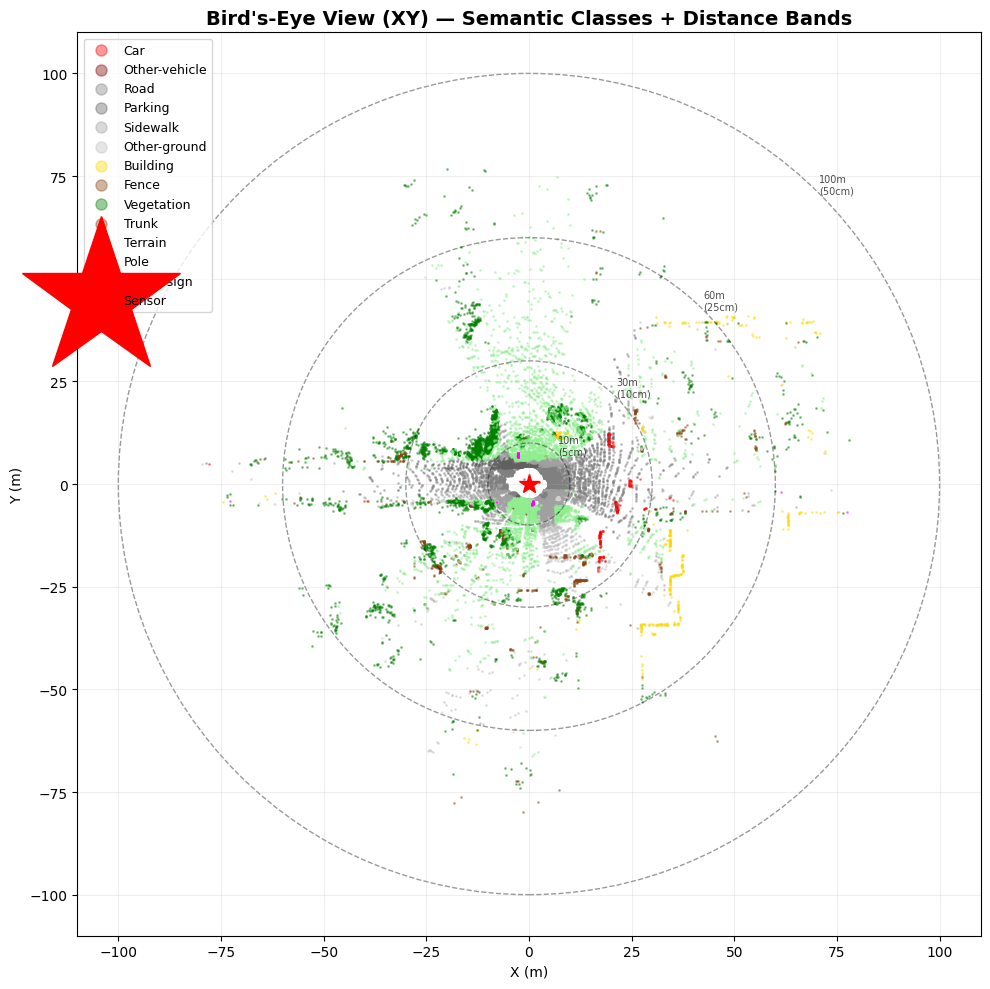

✓ Saved: vis_02_birdseye_xy.png


In [11]:
fig, ax = plt.subplots(figsize=(14, 10))

for label_id in sorted(LABEL_NAMES.keys()):
    mask = labels[vis_idx] == label_id
    if mask.sum() == 0:
        continue
    pts = points_xyz[vis_idx][mask]
    ax.scatter(
        pts[:, 0], pts[:, 1],
        c=CLASS_COLORS[label_id],
        s=1, alpha=0.4,
        label=LABEL_NAMES[label_id]
    )

# Draw radial distance bands as circles
for r_min, r_max, res in DISTANCE_BANDS:
    circle = plt.Circle(
        (SENSOR_ORIGIN[0], SENSOR_ORIGIN[1]), r_max,
        fill=False, linestyle='--', linewidth=1.0,
        edgecolor='black', alpha=0.4
    )
    ax.add_patch(circle)
    ax.annotate(
        f"{r_max}m\n({res*100:.0f}cm)",
        xy=(SENSOR_ORIGIN[0] + r_max * 0.707, SENSOR_ORIGIN[1] + r_max * 0.707),
        fontsize=7, color='black', alpha=0.7,
        ha='left'
    )

# Mark sensor origin
ax.plot(*SENSOR_ORIGIN[:2], 'r*', markersize=15, label='Sensor', zorder=10)

ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_title("Bird's-Eye View (XY) — Semantic Classes + Distance Bands", fontsize=14, fontweight='bold')
ax.legend(loc='upper left', markerscale=8, fontsize=9)
ax.set_aspect('equal')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig("vis_02_birdseye_xy.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: vis_02_birdseye_xy.png")

### 8.3 — Side View (XZ) — Elevation Profile

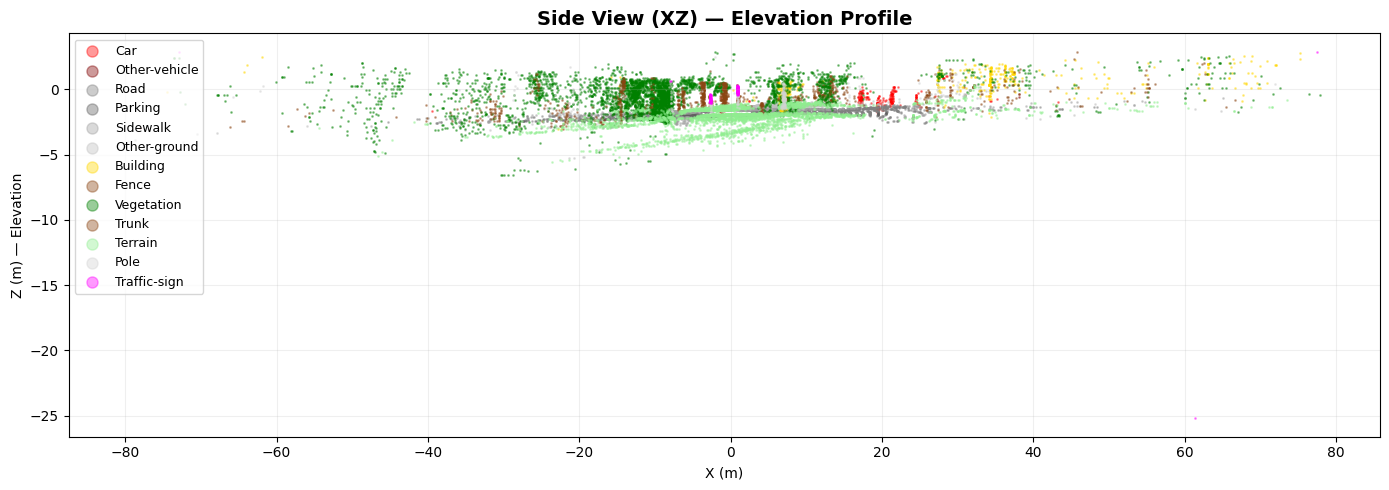

✓ Saved: vis_03_side_xz.png


In [12]:
fig, ax = plt.subplots(figsize=(14, 5))

for label_id in sorted(LABEL_NAMES.keys()):
    mask = labels[vis_idx] == label_id
    if mask.sum() == 0:
        continue
    pts = points_xyz[vis_idx][mask]
    ax.scatter(
        pts[:, 0], pts[:, 2],
        c=CLASS_COLORS[label_id],
        s=1, alpha=0.4,
        label=LABEL_NAMES[label_id]
    )

ax.set_xlabel("X (m)")
ax.set_ylabel("Z (m) — Elevation")
ax.set_title("Side View (XZ) — Elevation Profile", fontsize=14, fontweight='bold')
ax.legend(loc='upper left', markerscale=8, fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig("vis_03_side_xz.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: vis_03_side_xz.png")

### 8.4 — Radial Distance Histogram

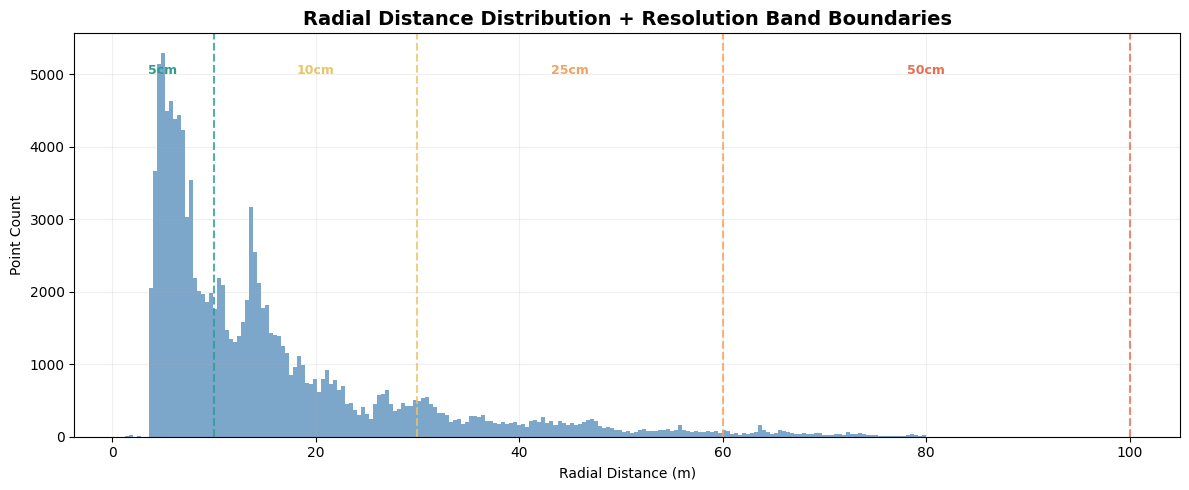

✓ Saved: vis_04_radial_histogram.png


In [13]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(radial_distance, bins=200, color='steelblue', alpha=0.7, edgecolor='none')

# Mark band boundaries
band_colors = ['#2A9D8F', '#E9C46A', '#F4A261', '#E76F51']
for i, (r_min, r_max, res) in enumerate(DISTANCE_BANDS):
    ax.axvline(r_max, color=band_colors[i], linestyle='--', linewidth=1.5, alpha=0.8)
    ax.text(
        (r_min + r_max) / 2, ax.get_ylim()[1] * 0.9,
        f"{res*100:.0f}cm",
        ha='center', fontsize=9, color=band_colors[i], fontweight='bold'
    )

ax.set_xlabel("Radial Distance (m)")
ax.set_ylabel("Point Count")
ax.set_title("Radial Distance Distribution + Resolution Band Boundaries", fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig("vis_04_radial_histogram.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: vis_04_radial_histogram.png")

### 8.5 — Per-Class Radial Distribution

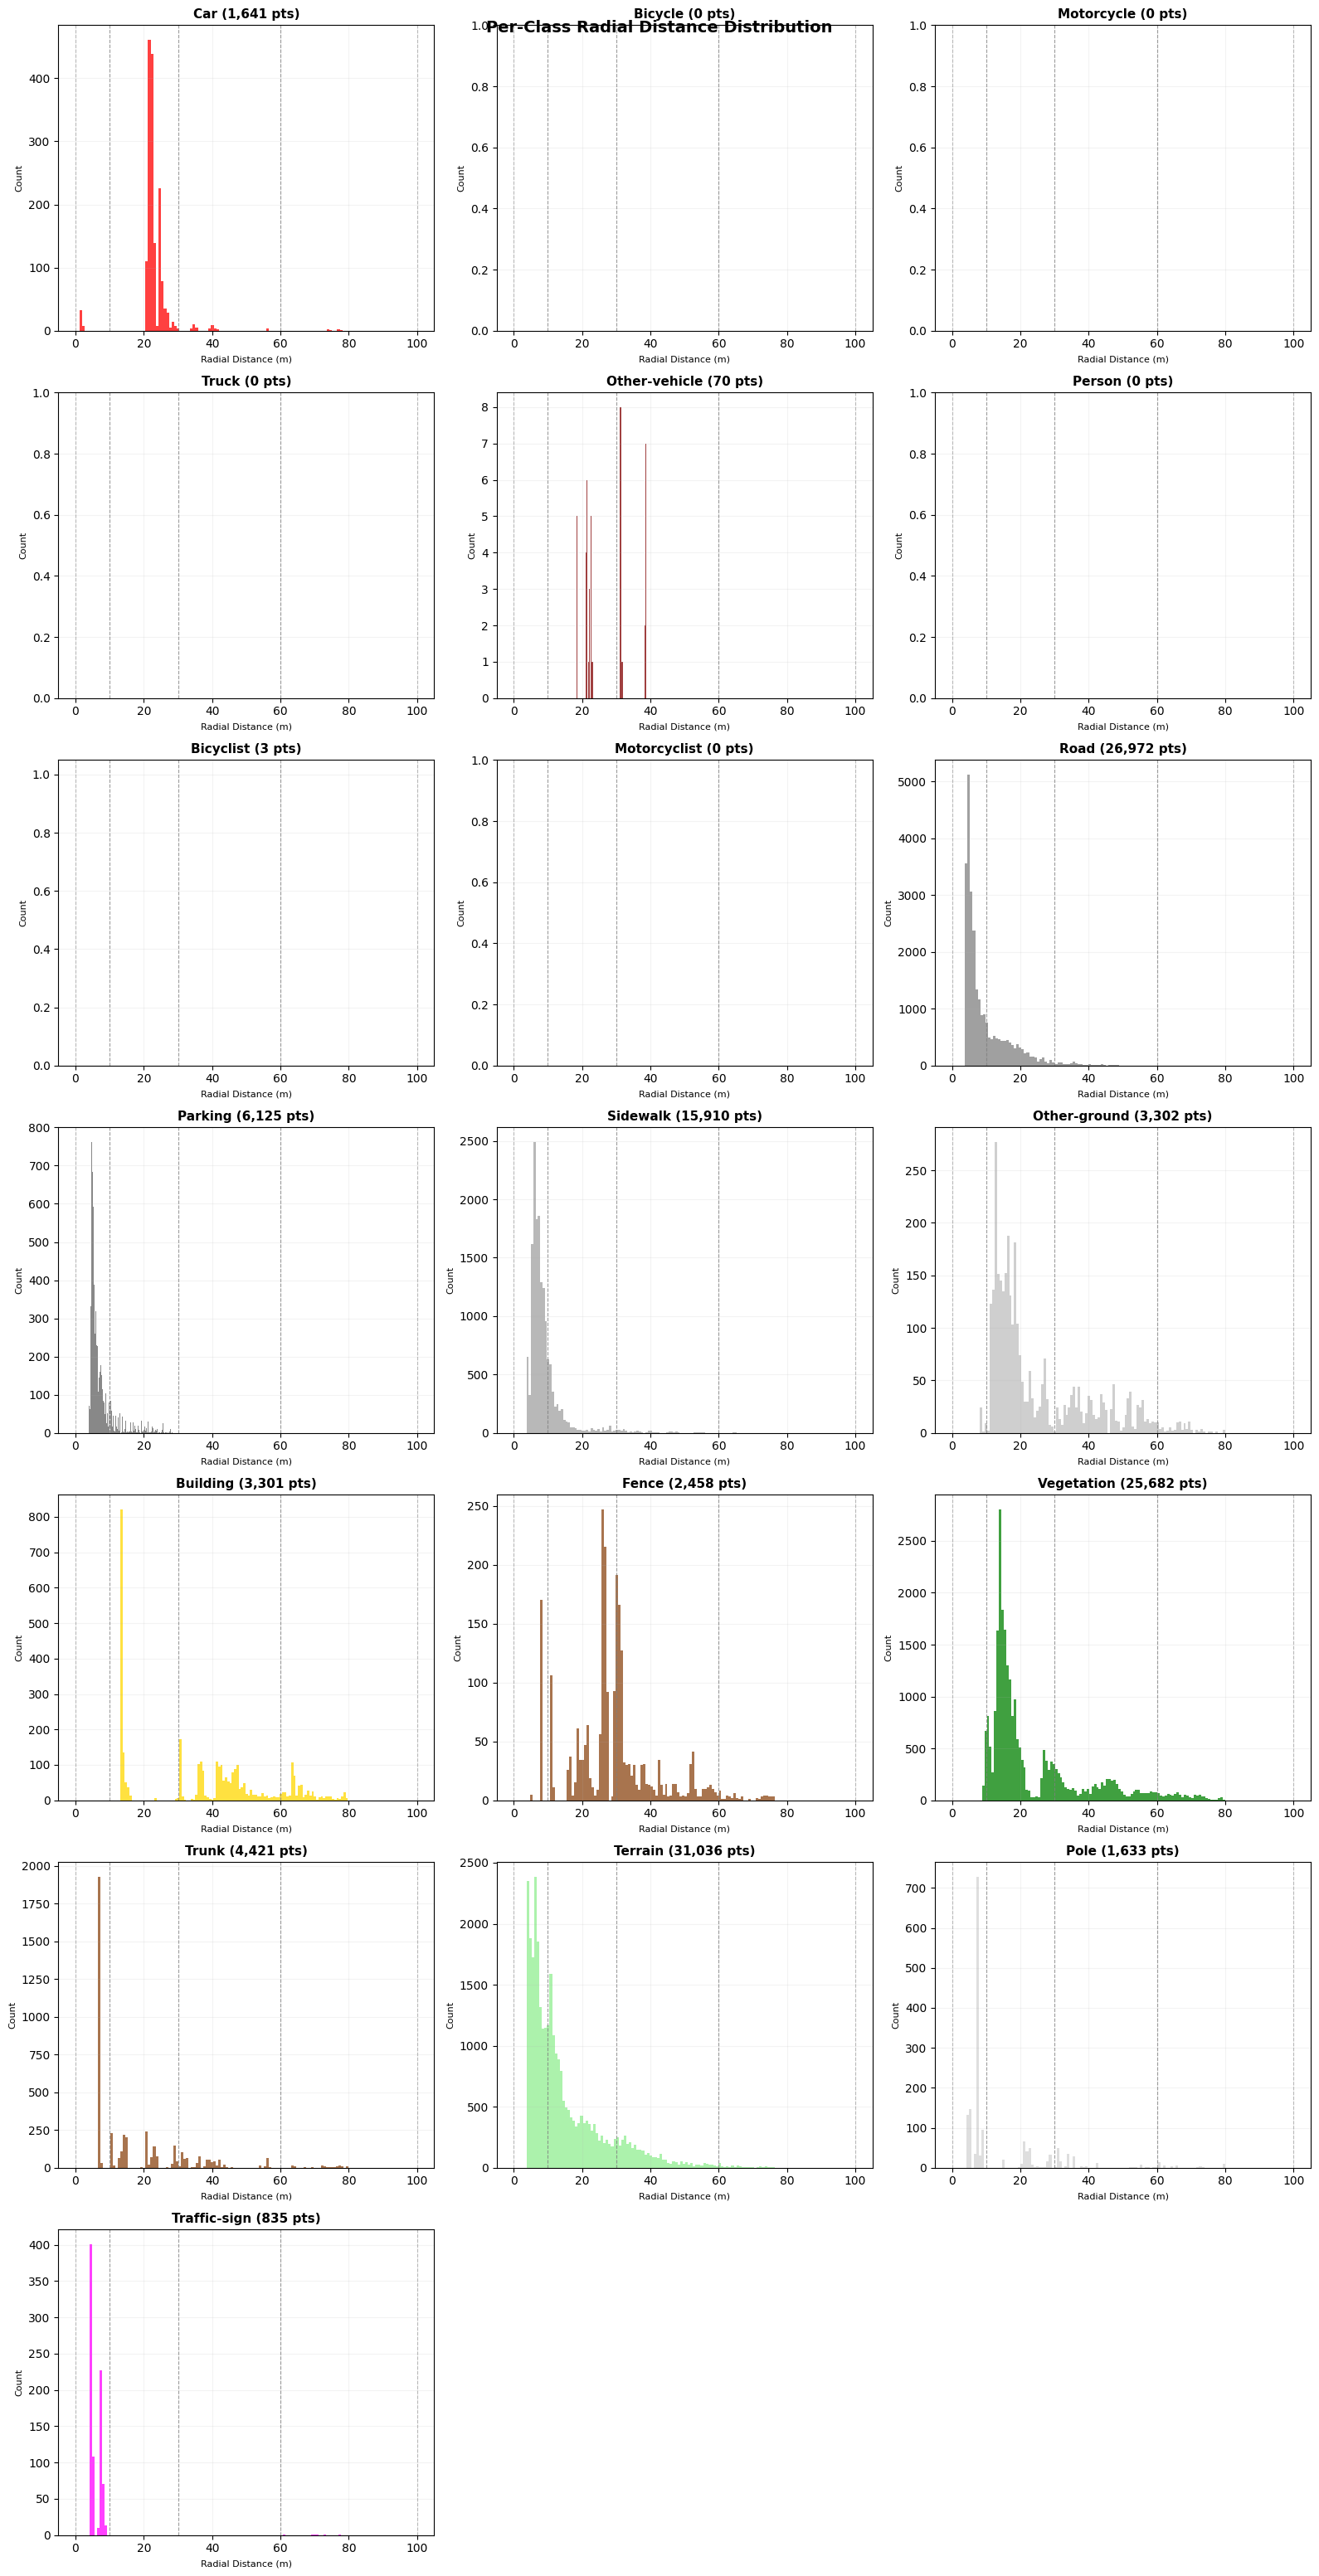

✓ Saved: vis_05_perclass_radial.png


In [15]:
import math

# Number of semantic classes
class_ids = sorted(LABEL_NAMES.keys())
n_classes = len(class_ids)

# Automatically create enough subplot spaces
ncols = 3
nrows = math.ceil(n_classes / ncols)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(16, 4.5 * nrows)
)

# Always make axes 1-dimensional
axes = np.atleast_1d(axes).flatten()

for idx, label_id in enumerate(class_ids):

    ax = axes[idx]

    mask = (labels == label_id)
    r = radial_distance[mask]

    # Plot only if this class has points
    if len(r) > 0:
        ax.hist(
            r,
            bins=100,
            color=CLASS_COLORS[label_id],
            alpha=0.75,
            edgecolor='none'
        )

    # Band boundaries
    for r_min, r_max, res in DISTANCE_BANDS:
        ax.axvline(
            r_min,
            color='gray',
            linestyle='--',
            linewidth=0.8,
            alpha=0.5
        )

        ax.axvline(
            r_max,
            color='gray',
            linestyle='--',
            linewidth=0.8,
            alpha=0.5
        )

    ax.set_title(
        f"{LABEL_NAMES[label_id]} ({mask.sum():,} pts)",
        fontsize=11,
        fontweight='bold'
    )

    ax.set_xlabel("Radial Distance (m)", fontsize=8)
    ax.set_ylabel("Count", fontsize=8)
    ax.grid(True, alpha=0.15)

# Hide unused subplot(s)
for idx in range(n_classes, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle(
    "Per-Class Radial Distance Distribution",
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    "vis_05_perclass_radial.png",
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print("✓ Saved: vis_05_perclass_radial.png")

## 9. Clean Output Preparation for Phase 2

In [17]:
# ── Package all validated data ──────────────────────────────────
output_file = "phase1_output.npz"

# Metadata as a dictionary (stored as a 0-d object array for npz compatibility)
metadata = {
    "n_points": int(N_POINTS),
    "sensor_origin": SENSOR_ORIGIN.tolist(),
    "label_names": LABEL_NAMES,
    "valid_labels": sorted(list(VALID_LABELS)),
    "map_bounds": map_bounds,
    "distance_bands": DISTANCE_BANDS,
    "boundary_padding_m": float(BOUNDARY_PADDING_M),
    "source_file": DATA_FILE,
}

np.savez(
    output_file,
    points_xyz=points_xyz.astype(np.float64),
    labels=labels,
    confidence=confidence,
    intensity=intensity,
    radial_distance=radial_distance.astype(np.float64),
    metadata=np.array(metadata),   # stored as object array
)

# ── Verify the saved file ──────────────────────────────────────
verify = np.load(output_file, allow_pickle=True)
print("Saved and verified: phase1_output.npz")
print(f"  Keys: {list(verify.keys())}")
print(f"  points_xyz  : {verify['points_xyz'].shape}")
print(f"  labels      : {verify['labels'].shape}")
print(f"  confidence  : {verify['confidence'].shape}")
print(f"  intensity   : {verify['intensity'].shape}")
print(f"  radial_dist : {verify['radial_distance'].shape}")

# Final consistency check
assert verify['points_xyz'].shape[0] == N_POINTS
assert verify['labels'].shape[0] == N_POINTS
assert verify['confidence'].shape[0] == N_POINTS
assert verify['intensity'].shape[0] == N_POINTS
assert verify['radial_distance'].shape[0] == N_POINTS

print(f"\n✓ Output file ready — {N_POINTS} points packaged for Phase 2")
print(f"  File size: {os.path.getsize(output_file) / 1024:.1f} KB")

Saved and verified: phase1_output.npz
  Keys: ['points_xyz', 'labels', 'confidence', 'intensity', 'radial_distance', 'metadata']
  points_xyz  : (123389, 3)
  labels      : (123389,)
  confidence  : (123389,)
  intensity   : (123389,)
  radial_dist : (123389,)

✓ Output file ready — 123389 points packaged for Phase 2
  File size: 5304.2 KB


## Summary

**Phase 1 Complete.** Results:

| Item | Status |
|------|--------|
| Data loaded | ✓ |
| Shape validated | ✓ |
| NaN/Inf checks | ✓ |
| Label validation | ✓ |
| Confidence/Intensity range | ✓ |
| Radial distances computed | ✓ |
| Map boundaries established | ✓ |
| 5 visualizations generated | ✓ |
| Clean output saved | ✓ |

**Next → Phase 2: Radial Base Grid**
- Will load `phase1_output.npz`
- Assign points to distance-dependent resolution bands
- Create initial base grid cells